<a href="https://colab.research.google.com/github/Tamaki-Baba/data-Econometrics/blob/main/%E3%83%86%E3%82%99%E3%83%BC%E3%82%BF%E3%81%A8%E8%A8%88%E9%87%8F%E7%B5%8C%E6%B8%88%E5%AD%A6_0108.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

•grades.csvは100人の10問で1問1点10点満点のテストの結果である。


•MCMC法を用いて平均点とその分布を求めてみよう

Output()

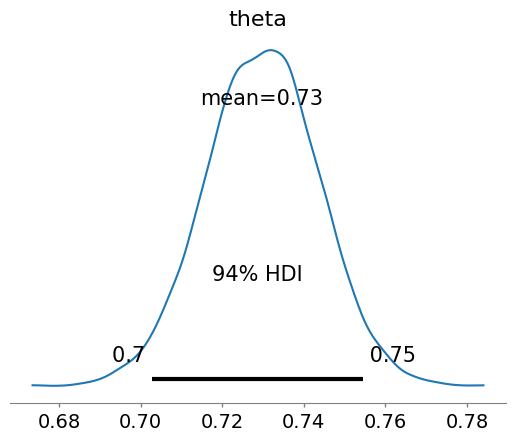

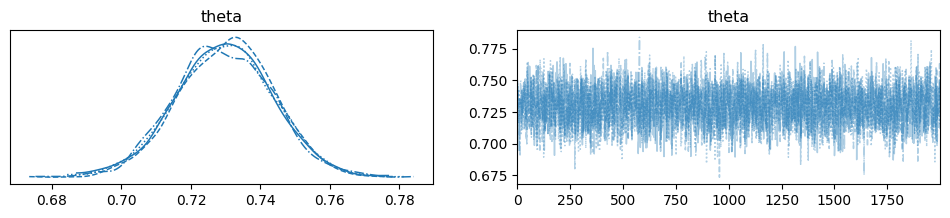

In [ ]:
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# データ読み込み
data = pd.read_csv("grades.csv", header=None)[0].values

with pm.Model() as model:
    # 事前分布（一様分布）
    theta = pm.Uniform("theta", lower=0, upper=1)

    # 尤度（二項分布）
    y = pm.Binomial("y", n=10, p=theta, observed=data)

    # MCMCサンプリング
    trace = pm.sample(
        2000,
        tune=1000,
        chains=4,
        random_seed=42,
        return_inferencedata=True
    )

# 結果の要約
az.summary(trace, var_names=["theta"])

# 事後分布の表示
az.plot_posterior(trace, var_names=["theta"])
plt.show()

# 収束確認
az.plot_trace(trace, var_names=["theta"])
plt.show()

